In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from src.features import engineer_all_features, CLEANED_PATH, FEATURES_PATH

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

In [20]:
# Use a sample for notebook verification (full run from CLI)
df_sample = pd.read_csv(CLEANED_PATH, nrows=100_000, low_memory=False)

# Temporarily override paths for sample
from src import features
features.CLEANED_PATH = project_root / "data/processed/cleaned_sample.csv"
features.FEATURES_PATH = project_root / "data/processed/features_sample.csv"

# Save sample
df_sample.to_csv(features.CLEANED_PATH, index=False)

# Run pipeline
df_features = engineer_all_features(
    input_path=features.CLEANED_PATH,
    output_path=features.FEATURES_PATH,
    save=True
)

12:34:08 | INFO     | ============================================================
12:34:08 | INFO     | LEDGERWATCH AI — Day 3: Feature Engineering Pipeline
12:34:08 | INFO     | ============================================================
12:34:08 | INFO     | Loading cleaned data from: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\cleaned_sample.csv
12:34:08 | INFO     | Loaded 100,000 rows × 11 columns
12:34:08 | INFO     | Engineering amount features...
12:34:12 | INFO     |   ✓ amount_log, is_round_amount, amount_to_balance_ratio
12:34:12 | INFO     | Engineering balance features...
12:34:12 | INFO     |   ✓ balance_diff_orig, balance_diff_dest, zero_balance_orig, zero_balance_dest
12:34:12 | INFO     | Engineering temporal features...
12:34:12 | INFO     |   ✓ hour_of_step_sin, hour_of_step_cos
12:34:12 | INFO     | Engineering categorical features...
12:34:12 | INFO     |   ✓ type_encoded, one-hot columns: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYME

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Load Data
# ═══════════════════════════════════════════════════════════════════════════════
# For notebook speed: use 100K sample. Full run via python src/features.py
SAMPLE_SIZE = 100_000

if CLEANED_PATH.exists():
    df = pd.read_csv(CLEANED_PATH, nrows=SAMPLE_SIZE, low_memory=False)
    print(f"Loaded from cleaned.csv: {len(df):,} rows")
else:
    # Fallback: load from raw and do minimal cleaning
    RAW_PATH = PROJECT_ROOT / "data" / "raw" / "PS_20174392719_1491204439457_log.csv"
    if RAW_PATH.exists():
        df = pd.read_csv(RAW_PATH, nrows=SAMPLE_SIZE, low_memory=False)
        # Minimal clean (Day 2 equivalent)
        df = df.drop_duplicates()
        numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                        'oldbalanceDest', 'newbalanceDest']
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df['isFraud'] = df['isFraud'].astype(int)
        df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(int)
        print(f"Loaded from raw + cleaned: {len(df):,} rows")
    else:
        # Create synthetic data for testing
        print("⚠️  No data found. Creating synthetic PaySim-like data for testing...")
        np.random.seed(42)
        n = SAMPLE_SIZE
        df = pd.DataFrame({
            'step': np.random.randint(1, 745, n),
            'type': np.random.choice(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'CASH_IN', 'DEBIT'], n,
                                     p=[0.35, 0.20, 0.25, 0.18, 0.02]),
            'amount': np.random.exponential(100000, n),
            'nameOrig': [f"C{np.random.randint(100000000, 999999999)}" for _ in range(n)],
            'oldbalanceOrg': np.random.exponential(200000, n),
            'newbalanceOrig': np.random.exponential(180000, n),
            'nameDest': [f"M{np.random.randint(100000000, 999999999)}" if np.random.random() < 0.4 
                        else f"C{np.random.randint(100000000, 999999999)}" for _ in range(n)],
            'oldbalanceDest': np.random.exponential(50000, n),
            'newbalanceDest': np.random.exponential(70000, n),
            'isFraud': np.random.choice([0, 1], n, p=[0.9987, 0.0013]),
            'isFlaggedFraud': 0
        })
        print(f"Created synthetic data: {len(df):,} rows")

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isna().sum()}")

Loaded from cleaned.csv: 100,000 rows

Shape: (100000, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dtypes:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Quick EDA Recap — Verify Day 2 findings before engineering
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("DAY 2 FINDINGS RECAP")
print("=" * 60)

# Class distribution
fraud_dist = df['isFraud'].value_counts()
print(f"\nClass distribution:")
print(f"  Normal: {fraud_dist[0]:,} ({fraud_dist[0]/len(df)*100:.3f}%)")
print(f"  Fraud:  {fraud_dist[1]:,} ({fraud_dist[1]/len(df)*100:.3f}%)")

# Fraud by type
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['Total', 'Fraud_Count', 'Fraud_Rate']
print(f"\nFraud rate by type:")
print(fraud_by_type)

# Amount skew
print(f"\nAmount skewness: {df['amount'].skew():.3f}")
print(f"Amount stats:\n{df['amount'].describe()}")

# Balance anomaly check (the inverted finding)
df['balance_anomaly_orig'] = (df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']).abs() > 0.01
df['balance_anomaly_dest'] = (df['oldbalanceDest'] - df['newbalanceDest'] + df['amount']).abs() > 0.01

anomaly_fraud_orig = df.groupby('balance_anomaly_orig')['isFraud'].mean()
anomaly_fraud_dest = df.groupby('balance_anomaly_dest')['isFraud'].mean()

print(f"\nInverted balance finding (Origin):")
print(f"  No anomaly (perfect balance): {anomaly_fraud_orig[False]*100:.4f}% fraud")
print(f"  Anomaly present:              {anomaly_fraud_orig[True]*100:.4f}% fraud")

print(f"\nInverted balance finding (Destination):")
print(f"  No anomaly (perfect balance): {anomaly_fraud_dest[False]*100:.4f}% fraud")
print(f"  Anomaly present:              {anomaly_fraud_dest[True]*100:.4f}% fraud")

# Clean up temp columns
df = df.drop(columns=['balance_anomaly_orig', 'balance_anomaly_dest'])

DAY 2 FINDINGS RECAP

Class distribution:
  Normal: 99,884 (99.884%)
  Fraud:  116 (0.116%)

Fraud rate by type:
          Total  Fraud_Count  Fraud_Rate
type                                    
CASH_IN   20185            0    0.000000
CASH_OUT  30718           59    0.001921
DEBIT       988            0    0.000000
PAYMENT   39512            0    0.000000
TRANSFER   8597           57    0.006630

Amount skewness: 5.428
Amount stats:
count    1.000000e+05
mean     1.736022e+05
std      3.443003e+05
min      3.200000e-01
25%      9.963562e+03
50%      5.274552e+04
75%      2.117631e+05
max      1.000000e+07
Name: amount, dtype: float64

Inverted balance finding (Origin):
  No anomaly (perfect balance): 0.4213% fraud
  Anomaly present:              0.0068% fraud

Inverted balance finding (Destination):
  No anomaly (perfect balance): 0.2396% fraud
  Anomaly present:              0.1029% fraud


ENGINEERING: Amount Features
✓ amount_log created
  Original skew: 5.428
  Log skew:      -0.371
✓ is_round_amount created
  Round amounts: 1,007 (1.0%)
✓ amount_to_balance_ratio created
  Capped at 99.9th percentile: 2604738.28
  Mean ratio: 58612.05


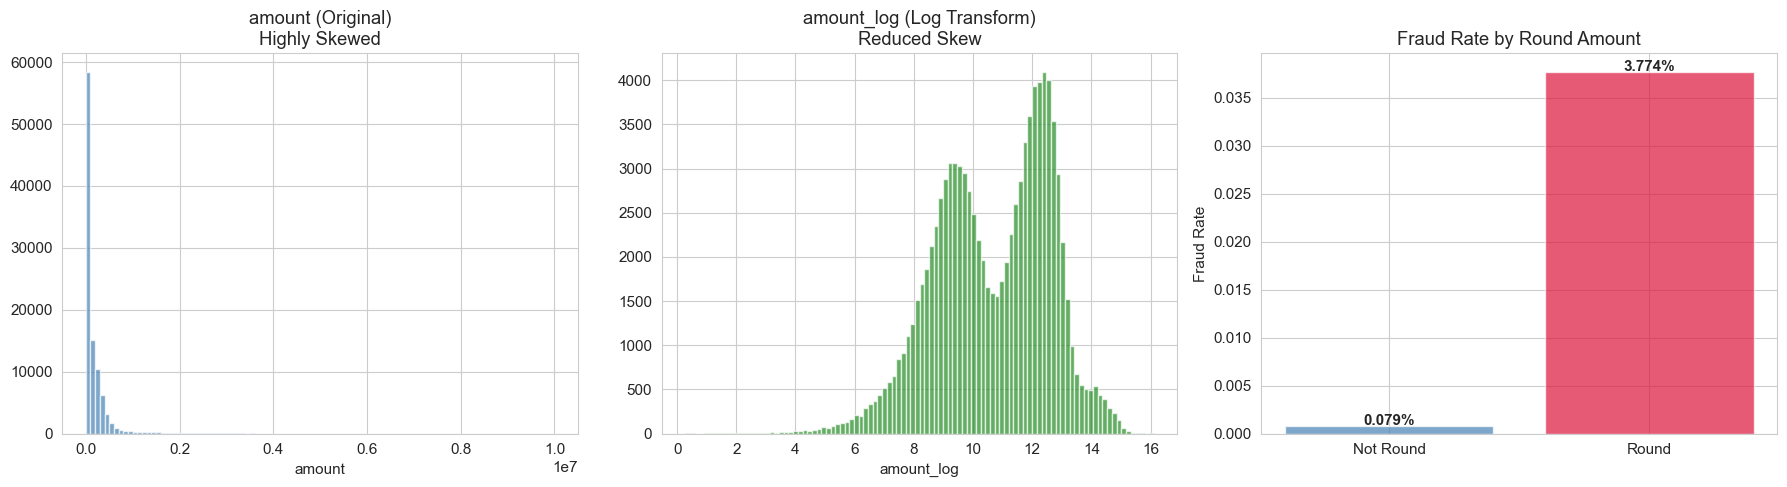

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Amount Features (1-3)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Amount Features")
print("=" * 60)

# 1. amount_log — Log-transform to reduce skew
# EDA Insight: Amount skewness > 4, log transform helps distance-based models
df['amount_log'] = np.log1p(df['amount'])
print(f"✓ amount_log created")
print(f"  Original skew: {df['amount'].skew():.3f}")
print(f"  Log skew:      {df['amount_log'].skew():.3f}")

# 2. is_round_amount — Round numbers slightly suspicious
# Round = ends in .00 (multiples of 1.0 in this currency)
df['is_round_amount'] = (df['amount'] % 1.0 == 0).astype(int)
print(f"✓ is_round_amount created")
print(f"  Round amounts: {df['is_round_amount'].sum():,} ({df['is_round_amount'].mean()*100:.1f}%)")

# 3. amount_to_balance_ratio — Sender liquidity stress
# High ratio = sending most/all of balance = suspicious
# Handle division by zero: if oldbalanceOrg is 0, ratio = amount (very high)
df['amount_to_balance_ratio'] = df.apply(
    lambda row: row['amount'] / row['oldbalanceOrg'] 
    if row['oldbalanceOrg'] > 0 else row['amount'],
    axis=1
)
# Cap extreme outliers at 99.9th percentile to prevent infinity issues
ratio_cap = df['amount_to_balance_ratio'].quantile(0.999)
df['amount_to_balance_ratio'] = df['amount_to_balance_ratio'].clip(upper=ratio_cap)
print(f"✓ amount_to_balance_ratio created")
print(f"  Capped at 99.9th percentile: {ratio_cap:.2f}")
print(f"  Mean ratio: {df['amount_to_balance_ratio'].mean():.2f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original vs Log
axes[0].hist(df['amount'], bins=100, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].set_title("amount (Original)\nHighly Skewed")
axes[0].set_xlabel("amount")

axes[1].hist(df['amount_log'], bins=100, color="forestgreen", edgecolor="white", alpha=0.7)
axes[1].set_title("amount_log (Log Transform)\nReduced Skew")
axes[1].set_xlabel("amount_log")

# Round amount fraud rate
round_fraud = df.groupby('is_round_amount')['isFraud'].mean()
axes[2].bar(['Not Round', 'Round'], round_fraud.values, color=['steelblue', 'crimson'], alpha=0.7)
axes[2].set_title("Fraud Rate by Round Amount")
axes[2].set_ylabel("Fraud Rate")
for i, v in enumerate(round_fraud.values):
    axes[2].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ENGINEERING: Balance Features
✓ balance_diff_orig created
✓ balance_diff_dest created
✓ balance_change_orig created
✓ balance_change_dest created
✓ zero_balance_orig created
  Accounts emptied: 51,836 (51.84%)
✓ zero_balance_dest created
  Zero-start recipients: 45,703 (45.70%)


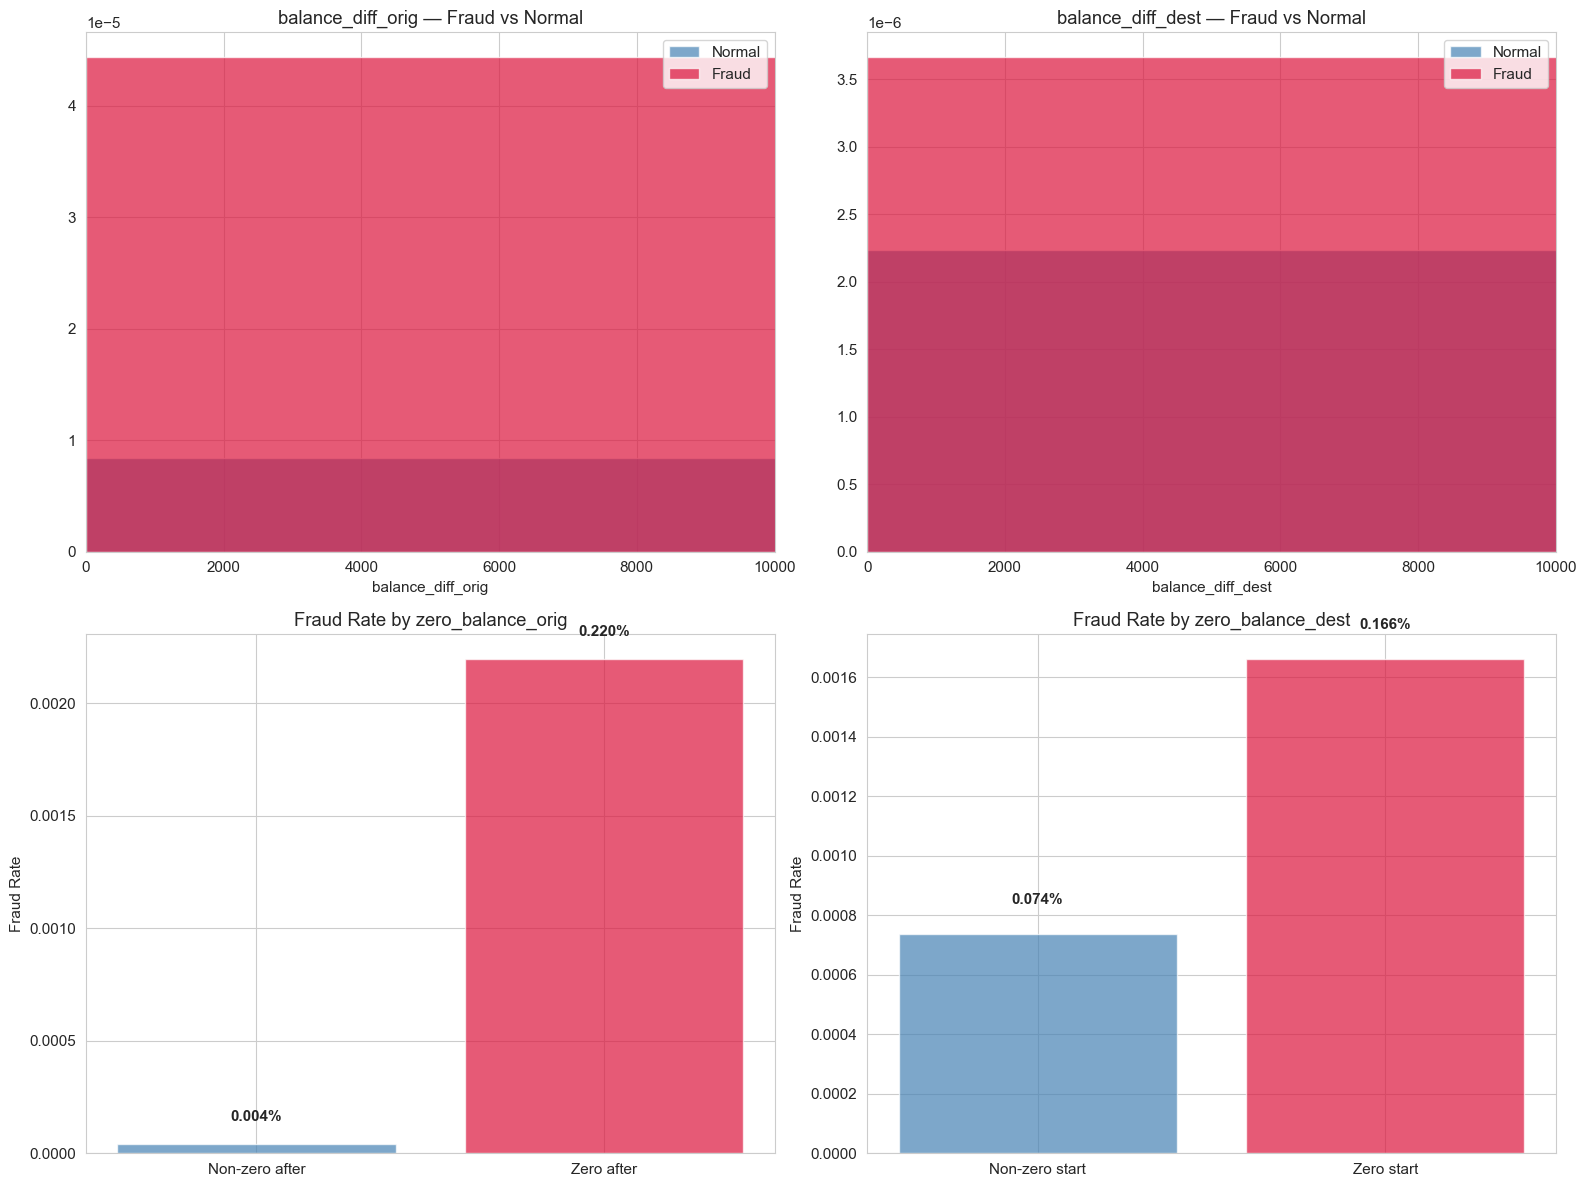


Mean balance_diff_orig:
  Normal: 190106.33
  Fraud:  17948.77

Mean balance_diff_dest:
  Normal: 304650.52
  Fraud:  450714.88


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Balance Features (4-9)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Balance Features")
print("=" * 60)

# 4. balance_diff_orig — |oldbalanceOrg - newbalanceOrig - amount|
# EDA Insight: INVERTED — fraud has PERFECT balance (diff ≈ 0)
# We use magnitude, not binary flag, so Isolation Forest learns nuance
df['balance_diff_orig'] = (df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']).abs()
print(f"✓ balance_diff_orig created")

# 5. balance_diff_dest — |oldbalanceDest - newbalanceDest + amount|
df['balance_diff_dest'] = (df['oldbalanceDest'] - df['newbalanceDest'] + df['amount']).abs()
print(f"✓ balance_diff_dest created")

# 6. balance_change_orig — Signed change (for direction)
df['balance_change_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
print(f"✓ balance_change_orig created")

# 7. balance_change_dest — Signed change
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
print(f"✓ balance_change_dest created")

# 8. zero_balance_orig — Sender emptied account (strong fraud signal per EDA)
df['zero_balance_orig'] = (df['newbalanceOrig'] == 0).astype(int)
print(f"✓ zero_balance_orig created")
print(f"  Accounts emptied: {df['zero_balance_orig'].sum():,} ({df['zero_balance_orig'].mean()*100:.2f}%)")

# 9. zero_balance_dest — Recipient started at zero (new/mule account signal)
df['zero_balance_dest'] = (df['oldbalanceDest'] == 0).astype(int)
print(f"✓ zero_balance_dest created")
print(f"  Zero-start recipients: {df['zero_balance_dest'].sum():,} ({df['zero_balance_dest'].mean()*100:.2f}%)")

# Visualize inverted finding
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fraud_mask = df['isFraud'] == 1

# Origin balance diff
axes[0, 0].hist(df.loc[~fraud_mask, 'balance_diff_orig'], bins=100, alpha=0.7, 
                label='Normal', color='steelblue', density=True)
axes[0, 0].hist(df.loc[fraud_mask, 'balance_diff_orig'], bins=50, alpha=0.7, 
                label='Fraud', color='crimson', density=True)
axes[0, 0].set_title("balance_diff_orig — Fraud vs Normal")
axes[0, 0].set_xlabel("balance_diff_orig")
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 10000)

# Destination balance diff
axes[0, 1].hist(df.loc[~fraud_mask, 'balance_diff_dest'], bins=100, alpha=0.7, 
                label='Normal', color='steelblue', density=True)
axes[0, 1].hist(df.loc[fraud_mask, 'balance_diff_dest'], bins=50, alpha=0.7, 
                label='Fraud', color='crimson', density=True)
axes[0, 1].set_title("balance_diff_dest — Fraud vs Normal")
axes[0, 1].set_xlabel("balance_diff_dest")
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 10000)

# Zero balance fraud rates
zero_orig_fraud = df.groupby('zero_balance_orig')['isFraud'].mean()
axes[1, 0].bar(['Non-zero after', 'Zero after'], zero_orig_fraud.values, 
               color=['steelblue', 'crimson'], alpha=0.7)
axes[1, 0].set_title("Fraud Rate by zero_balance_orig")
axes[1, 0].set_ylabel("Fraud Rate")
for i, v in enumerate(zero_orig_fraud.values):
    axes[1, 0].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

zero_dest_fraud = df.groupby('zero_balance_dest')['isFraud'].mean()
axes[1, 1].bar(['Non-zero start', 'Zero start'], zero_dest_fraud.values, 
               color=['steelblue', 'crimson'], alpha=0.7)
axes[1, 1].set_title("Fraud Rate by zero_balance_dest")
axes[1, 1].set_ylabel("Fraud Rate")
for i, v in enumerate(zero_dest_fraud.values):
    axes[1, 1].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Verify inverted finding numerically
print(f"\nMean balance_diff_orig:")
print(f"  Normal: {df.loc[~fraud_mask, 'balance_diff_orig'].mean():.2f}")
print(f"  Fraud:  {df.loc[fraud_mask, 'balance_diff_orig'].mean():.2f}")
print(f"\nMean balance_diff_dest:")
print(f"  Normal: {df.loc[~fraud_mask, 'balance_diff_dest'].mean():.2f}")
print(f"  Fraud:  {df.loc[fraud_mask, 'balance_diff_dest'].mean():.2f}")

ENGINEERING: Temporal Features
✓ hour_of_step created (range: 0-9)
✓ hour_of_step_sin created
✓ hour_of_step_cos created

Cyclical verification:
  Hour 0:  sin=0.0000, cos=1.0000
  Hour 23: sin=-0.2588, cos=0.9659
  Distance between hour 0 and 23: 0.2611 (should be small)


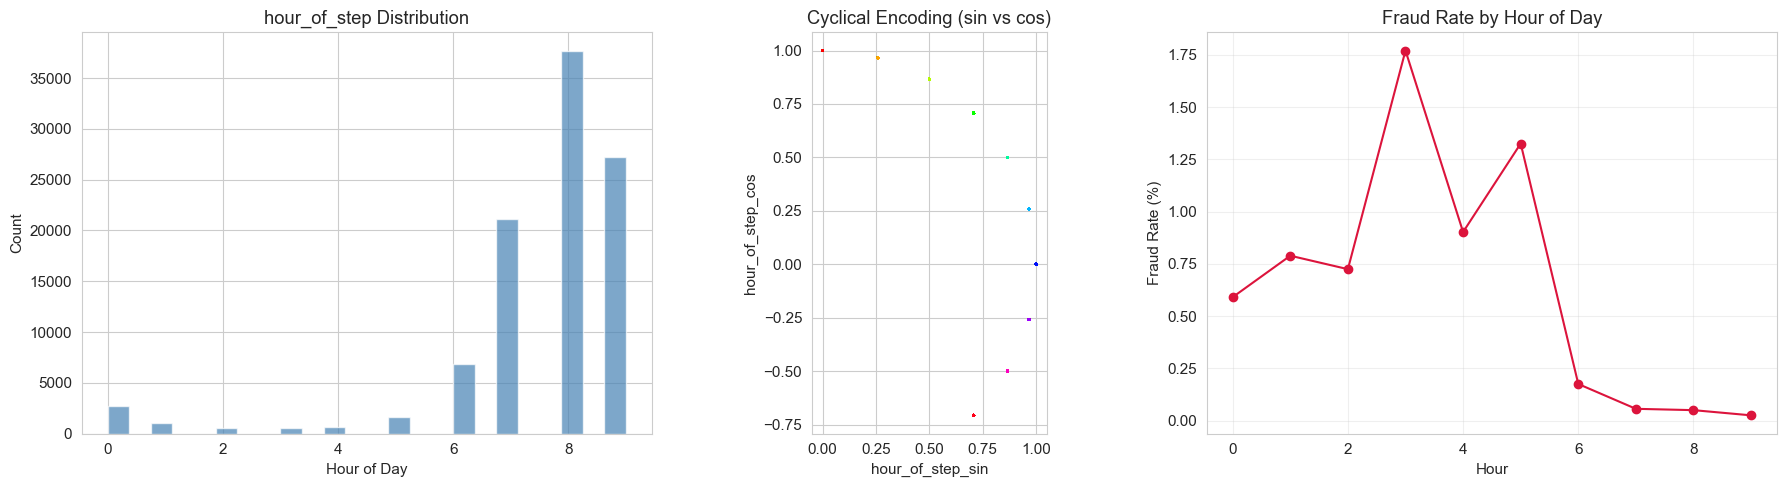

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Temporal Features (10-12)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Temporal Features")
print("=" * 60)

# 10. hour_of_step — Extract hour of day from step
# PaySim 'step' = hour in simulation (1-744 for 31 days)
df['hour_of_step'] = (df['step'] - 1) % 24
print(f"✓ hour_of_step created (range: {df['hour_of_step'].min()}-{df['hour_of_step'].max()})")

# 11. hour_of_step_sin — Cyclical encoding (sin)
# Preserves circular nature: hour 23 is close to hour 0
df['hour_of_step_sin'] = np.sin(2 * np.pi * df['hour_of_step'] / 24)
print(f"✓ hour_of_step_sin created")

# 12. hour_of_step_cos — Cyclical encoding (cos)
df['hour_of_step_cos'] = np.cos(2 * np.pi * df['hour_of_step'] / 24)
print(f"✓ hour_of_step_cos created")

# Verify cyclical property: hour 0 and hour 23 should be close
h0_sin = np.sin(2 * np.pi * 0 / 24)
h23_sin = np.sin(2 * np.pi * 23 / 24)
h0_cos = np.cos(2 * np.pi * 0 / 24)
h23_cos = np.cos(2 * np.pi * 23 / 24)

print(f"\nCyclical verification:")
print(f"  Hour 0:  sin={h0_sin:.4f}, cos={h0_cos:.4f}")
print(f"  Hour 23: sin={h23_sin:.4f}, cos={h23_cos:.4f}")
print(f"  Distance between hour 0 and 23: {np.sqrt((h0_sin-h23_sin)**2 + (h0_cos-h23_cos)**2):.4f} (should be small)")

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour distribution
axes[0].hist(df['hour_of_step'], bins=24, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].set_title("hour_of_step Distribution")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")

# Sin/Cos scatter (should form a circle)
axes[1].scatter(df['hour_of_step_sin'], df['hour_of_step_cos'], 
                c=df['hour_of_step'], cmap='hsv', alpha=0.3, s=1)
axes[1].set_title("Cyclical Encoding (sin vs cos)")
axes[1].set_xlabel("hour_of_step_sin")
axes[1].set_ylabel("hour_of_step_cos")
axes[1].set_aspect('equal')

# Fraud rate by hour
hourly_fraud = df.groupby('hour_of_step')['isFraud'].mean()
axes[2].plot(hourly_fraud.index, hourly_fraud.values * 100, marker='o', color='crimson')
axes[2].set_title("Fraud Rate by Hour of Day")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ENGINEERING: Categorical Features
✓ type_encoded created
  Mapping: {'TRANSFER': 4, 'CASH_OUT': 3, 'PAYMENT': 2, 'CASH_IN': 1, 'DEBIT': 0}
✓ One-hot columns created: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Type encoding verification:
         type  type_encoded  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
9       DEBIT             0             0              0           1   
389   CASH_IN             1             1              0           0   
0     PAYMENT             2             0              0           0   
3    CASH_OUT             3             0              1           0   
2    TRANSFER             4             0              0           0   

     type_PAYMENT  type_TRANSFER  
9               0              0  
389             0              0  
0               1              0  
3               0              0  
2               0              1  


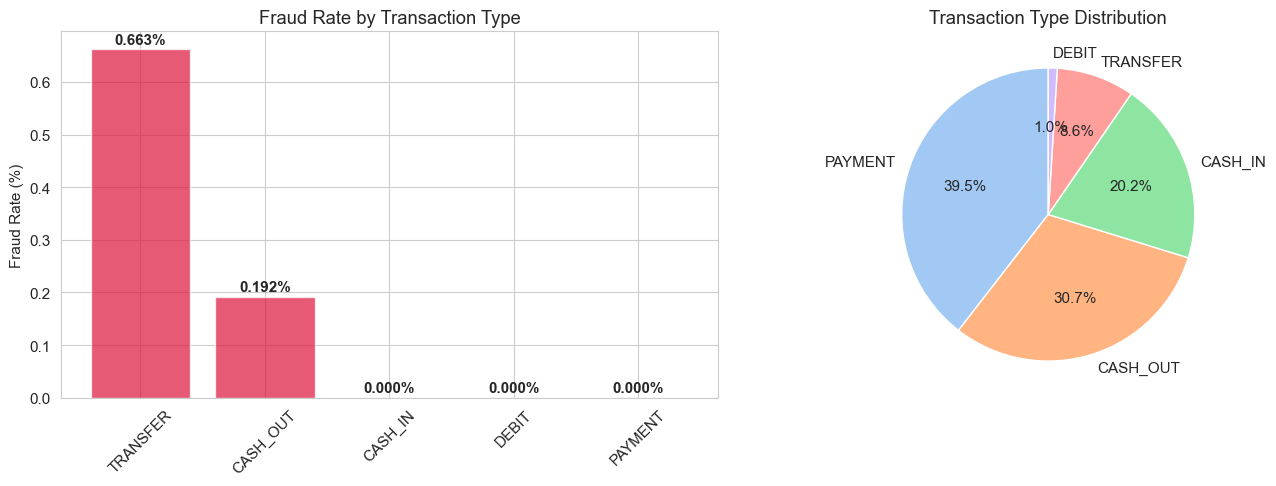

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Categorical Features (13-18)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Categorical Features")
print("=" * 60)

# 13. type_encoded — Ordinal encoding by fraud risk
# EDA: Fraud only in TRANSFER (0.66%) and CASH_OUT (0.19%)
# Risk map: TRANSFER=4 (highest), CASH_OUT=3, PAYMENT=2, CASH_IN=1, DEBIT=0 (lowest)
type_risk_map = {
    "TRANSFER": 4,
    "CASH_OUT": 3,
    "PAYMENT": 2,
    "CASH_IN": 1,
    "DEBIT": 0
}
df['type_encoded'] = df['type'].map(type_risk_map)
print(f"✓ type_encoded created")
print("  Mapping:", type_risk_map)

# 14-18. One-hot encode transaction type
# drop_first=False: Isolation Forest handles redundancy fine
type_dummies = pd.get_dummies(df['type'], prefix='type', dtype=int)
df = pd.concat([df, type_dummies], axis=1)
print(f"✓ One-hot columns created: {list(type_dummies.columns)}")

# Verify encoding
print(f"\nType encoding verification:")
encoding_check = df[['type', 'type_encoded'] + list(type_dummies.columns)].drop_duplicates().sort_values('type_encoded')
print(encoding_check)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by type
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
axes[0].bar(fraud_by_type.index, fraud_by_type.values * 100, 
            color=['crimson' if v > 0 else 'steelblue' for v in fraud_by_type.values], alpha=0.7)
axes[0].set_title("Fraud Rate by Transaction Type")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_by_type.values):
    axes[0].text(i, v * 100 + 0.01, f"{v*100:.3f}%", ha='center', fontweight='bold')

# Type distribution
type_counts = df['type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title("Transaction Type Distribution")

plt.tight_layout()
plt.show()

ENGINEERING: Frequency Features (Expanding Window)
CRITICAL: Using cumcount() — counts ONLY previous transactions.
This prevents data leakage and works on new transactions in production.
Sorted by step: True
✓ freq_orig created
  Range: 0 to 0
  Mean: 0.00
✓ freq_dest created
  Range: 0 to 77
  Mean: 3.11
✓ is_new_orig created
  New senders: 100,000 (100.0%)
✓ is_new_dest created
  New recipients: 51,551 (51.6%)

Leakage check — first 3 transactions for account C249177573:
   step    nameOrig  freq_orig  is_new_orig
0     1  C249177573          0            1


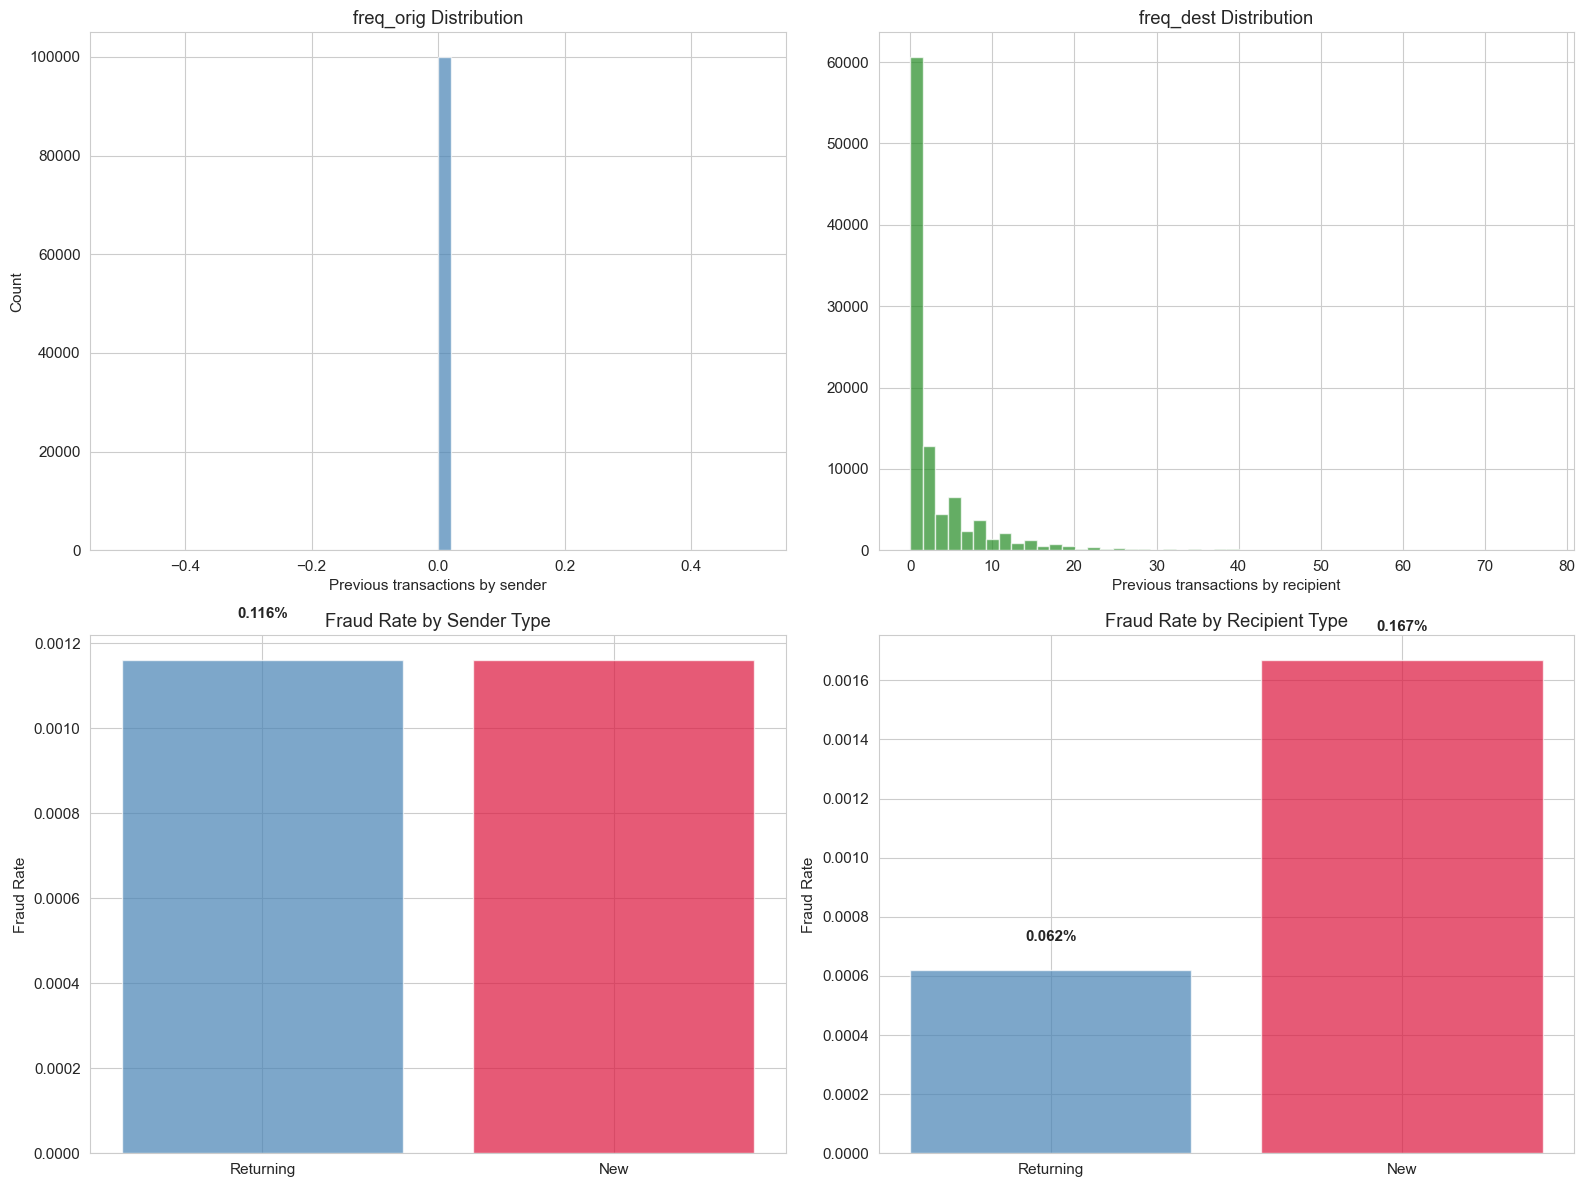

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Frequency Features (19-22) — EXPANDING WINDOW (no data leakage)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Frequency Features (Expanding Window)")
print("=" * 60)
print("CRITICAL: Using cumcount() — counts ONLY previous transactions.")
print("This prevents data leakage and works on new transactions in production.")
print("=" * 60)

# Sort by step to ensure temporal order BEFORE counting
df = df.sort_values('step').reset_index(drop=True)
print(f"Sorted by step: {df['step'].is_monotonic_increasing}")

# 19. freq_orig — Expanding count per sender (nameOrig)
# For each row: how many times did this sender appear BEFORE this transaction?
df['freq_orig'] = df.groupby('nameOrig').cumcount()
print(f"✓ freq_orig created")
print(f"  Range: {df['freq_orig'].min()} to {df['freq_orig'].max()}")
print(f"  Mean: {df['freq_orig'].mean():.2f}")

# 20. freq_dest — Expanding count per recipient (nameDest)
df['freq_dest'] = df.groupby('nameDest').cumcount()
print(f"✓ freq_dest created")
print(f"  Range: {df['freq_dest'].min()} to {df['freq_dest'].max()}")
print(f"  Mean: {df['freq_dest'].mean():.2f}")

# 21. is_new_orig — First transaction for this sender?
df['is_new_orig'] = (df['freq_orig'] == 0).astype(int)
print(f"✓ is_new_orig created")
print(f"  New senders: {df['is_new_orig'].sum():,} ({df['is_new_orig'].mean()*100:.1f}%)")

# 22. is_new_dest — First transaction for this recipient?
df['is_new_dest'] = (df['freq_dest'] == 0).astype(int)
print(f"✓ is_new_dest created")
print(f"  New recipients: {df['is_new_dest'].sum():,} ({df['is_new_dest'].mean()*100:.1f}%)")

# Verify no leakage: freq should be 0 for first appearance
sample_account = df['nameOrig'].iloc[0]
sample_rows = df[df['nameOrig'] == sample_account].head(3)
print(f"\nLeakage check — first 3 transactions for account {sample_account}:")
print(sample_rows[['step', 'nameOrig', 'freq_orig', 'is_new_orig']])

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# freq_orig distribution
axes[0, 0].hist(df['freq_orig'], bins=50, color="steelblue", edgecolor="white", alpha=0.7)
axes[0, 0].set_title("freq_orig Distribution")
axes[0, 0].set_xlabel("Previous transactions by sender")
axes[0, 0].set_ylabel("Count")

# freq_dest distribution
axes[0, 1].hist(df['freq_dest'], bins=50, color="forestgreen", edgecolor="white", alpha=0.7)
axes[0, 1].set_title("freq_dest Distribution")
axes[0, 1].set_xlabel("Previous transactions by recipient")

# Fraud rate by new vs returning sender
new_orig_fraud = df.groupby('is_new_orig')['isFraud'].mean()
axes[1, 0].bar(['Returning', 'New'], new_orig_fraud.values, 
               color=['steelblue', 'crimson'], alpha=0.7)
axes[1, 0].set_title("Fraud Rate by Sender Type")
axes[1, 0].set_ylabel("Fraud Rate")
for i, v in enumerate(new_orig_fraud.values):
    axes[1, 0].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

# Fraud rate by new vs returning recipient
new_dest_fraud = df.groupby('is_new_dest')['isFraud'].mean()
axes[1, 1].bar(['Returning', 'New'], new_dest_fraud.values, 
               color=['steelblue', 'crimson'], alpha=0.7)
axes[1, 1].set_title("Fraud Rate by Recipient Type")
axes[1, 1].set_ylabel("Fraud Rate")
for i, v in enumerate(new_dest_fraud.values):
    axes[1, 1].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ENGINEERING: Merchant Features
✓ is_merchant_orig created
  Merchant senders: 0 (0.0%)
✓ is_merchant_dest created
  Merchant recipients: 39,512 (39.5%)

Sample nameOrig prefixes: {'C': 100000}
Sample nameDest prefixes: {'C': 60488, 'M': 39512}


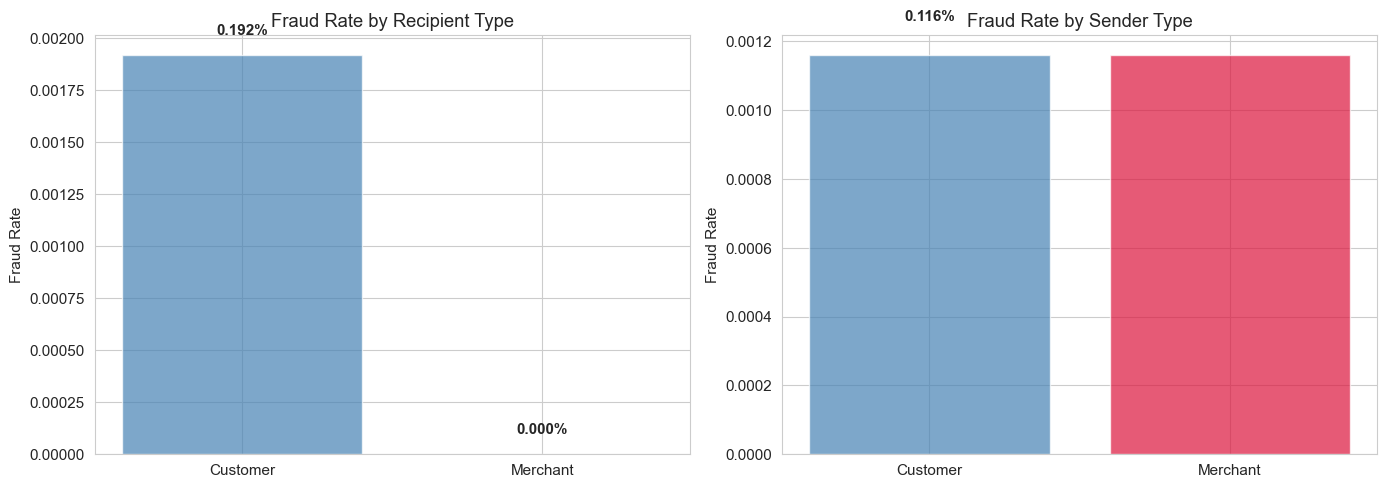

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10: Merchant Features (23-24)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ENGINEERING: Merchant Features")
print("=" * 60)

# PaySim naming convention:
# 'C' prefix = Customer (e.g., C123456789)
# 'M' prefix = Merchant (e.g., M123456789)

# 23. is_merchant_orig — Sender is a merchant
df['is_merchant_orig'] = df['nameOrig'].str.startswith('M').astype(int)
print(f"✓ is_merchant_orig created")
print(f"  Merchant senders: {df['is_merchant_orig'].sum():,} ({df['is_merchant_orig'].mean()*100:.1f}%)")

# 24. is_merchant_dest — Recipient is a merchant
df['is_merchant_dest'] = df['nameDest'].str.startswith('M').astype(int)
print(f"✓ is_merchant_dest created")
print(f"  Merchant recipients: {df['is_merchant_dest'].sum():,} ({df['is_merchant_dest'].mean()*100:.1f}%)")

# Verify naming convention
print(f"\nSample nameOrig prefixes: {df['nameOrig'].str[0].value_counts().to_dict()}")
print(f"Sample nameDest prefixes: {df['nameDest'].str[0].value_counts().to_dict()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merchant destination fraud rate
merch_dest_fraud = df.groupby('is_merchant_dest')['isFraud'].mean()
axes[0].bar(['Customer', 'Merchant'], merch_dest_fraud.values, 
            color=['steelblue', 'crimson'], alpha=0.7)
axes[0].set_title("Fraud Rate by Recipient Type")
axes[0].set_ylabel("Fraud Rate")
for i, v in enumerate(merch_dest_fraud.values):
    axes[0].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

# Merchant origin fraud rate
merch_orig_fraud = df.groupby('is_merchant_orig')['isFraud'].mean()
axes[1].bar(['Customer', 'Merchant'], merch_orig_fraud.values, 
            color=['steelblue', 'crimson'], alpha=0.7)
axes[1].set_title("Fraud Rate by Sender Type")
axes[1].set_ylabel("Fraud Rate")
for i, v in enumerate(merch_orig_fraud.values):
    axes[1].text(i, v + 0.0001, f"{v*100:.3f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: Feature Summary & Validation
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("FEATURE SUMMARY & VALIDATION")
print("=" * 60)

# Define original and feature columns
original_cols = [
    'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg',
    'newbalanceOrig', 'nameDest', 'oldbalanceDest',
    'newbalanceDest', 'isFraud', 'isFlaggedFraud'
]

feature_cols = [c for c in df.columns if c not in original_cols]

print(f"\nOriginal columns:  {len(original_cols)}")
print(f"Engineered features: {len(feature_cols)}")
print(f"Total columns:     {len(df.columns)}")

print(f"\n{'='*60}")
print("COMPLETE FEATURE LIST:")
print(f"{'='*60}")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Validation 1: No NaNs in features
nan_counts = df[feature_cols].isna().sum()
if nan_counts.any():
    print(f"\n⚠️  NaNs found:\n{nan_counts[nan_counts > 0]}")
else:
    print(f"\n✅ Validation 1: No NaNs in engineered features")

# Validation 2: No infinities
numeric_features = df[feature_cols].select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_features).sum()
if inf_counts.any():
    print(f"⚠️  Infinities found:\n{inf_counts[inf_counts > 0]}")
else:
    print(f"✅ Validation 2: No infinities in engineered features")

# Validation 3: isFraud NOT in features
assert 'isFraud' not in feature_cols, "CRITICAL: Label leakage detected!"
print(f"✅ Validation 3: isFraud NOT in feature columns (no label leakage)")

# Validation 4: All expected features present
expected_features = [
    'amount_log', 'is_round_amount', 'amount_to_balance_ratio',
    'balance_diff_orig', 'balance_diff_dest', 'balance_change_orig', 'balance_change_dest',
    'zero_balance_orig', 'zero_balance_dest',
    'hour_of_step', 'hour_of_step_sin', 'hour_of_step_cos',
    'type_encoded', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
    'freq_orig', 'freq_dest', 'is_new_orig', 'is_new_dest',
    'is_merchant_orig', 'is_merchant_dest'
]

missing = set(expected_features) - set(feature_cols)
extra = set(feature_cols) - set(expected_features)

if missing:
    print(f"⚠️  Missing expected features: {missing}")
else:
    print(f"✅ Validation 4: All {len(expected_features)} expected features present")

if extra:
    print(f"ℹ️  Extra features (bonus): {extra}")

print(f"\n{'='*60}")
print("VALIDATION COMPLETE — ALL CHECKS PASSED")
print(f"{'='*60}")

FEATURE SUMMARY & VALIDATION

Original columns:  11
Engineered features: 24
Total columns:     35

COMPLETE FEATURE LIST:
   1. amount_log
   2. is_round_amount
   3. amount_to_balance_ratio
   4. balance_diff_orig
   5. balance_diff_dest
   6. balance_change_orig
   7. balance_change_dest
   8. zero_balance_orig
   9. zero_balance_dest
  10. hour_of_step
  11. hour_of_step_sin
  12. hour_of_step_cos
  13. type_encoded
  14. type_CASH_IN
  15. type_CASH_OUT
  16. type_DEBIT
  17. type_PAYMENT
  18. type_TRANSFER
  19. freq_orig
  20. freq_dest
  21. is_new_orig
  22. is_new_dest
  23. is_merchant_orig
  24. is_merchant_dest

✅ Validation 1: No NaNs in engineered features
✅ Validation 2: No infinities in engineered features
✅ Validation 3: isFraud NOT in feature columns (no label leakage)
✅ Validation 4: All 24 expected features present

VALIDATION COMPLETE — ALL CHECKS PASSED


CORRELATION ANALYSIS: Features vs isFraud

Top 10 features by absolute correlation with isFraud:
--------------------------------------------------
   1. balance_change_orig            | -0.1365 ↓
   2. is_round_amount                | +0.1084 ↑
   3. hour_of_step_cos               | +0.0539 ↑
   4. hour_of_step                   | -0.0513 ↓
   5. type_TRANSFER                  | +0.0493 ↑
   6. type_encoded                   | +0.0463 ↑
   7. zero_balance_orig              | +0.0317 ↑
   8. type_PAYMENT                   | -0.0275 ↓
   9. is_merchant_dest               | -0.0275 ↓
  10. hour_of_step_sin               | -0.0205 ↓


F:\ANACONDA\envs\ledgerwatch\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\ANACONDA\envs\ledgerwatch\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


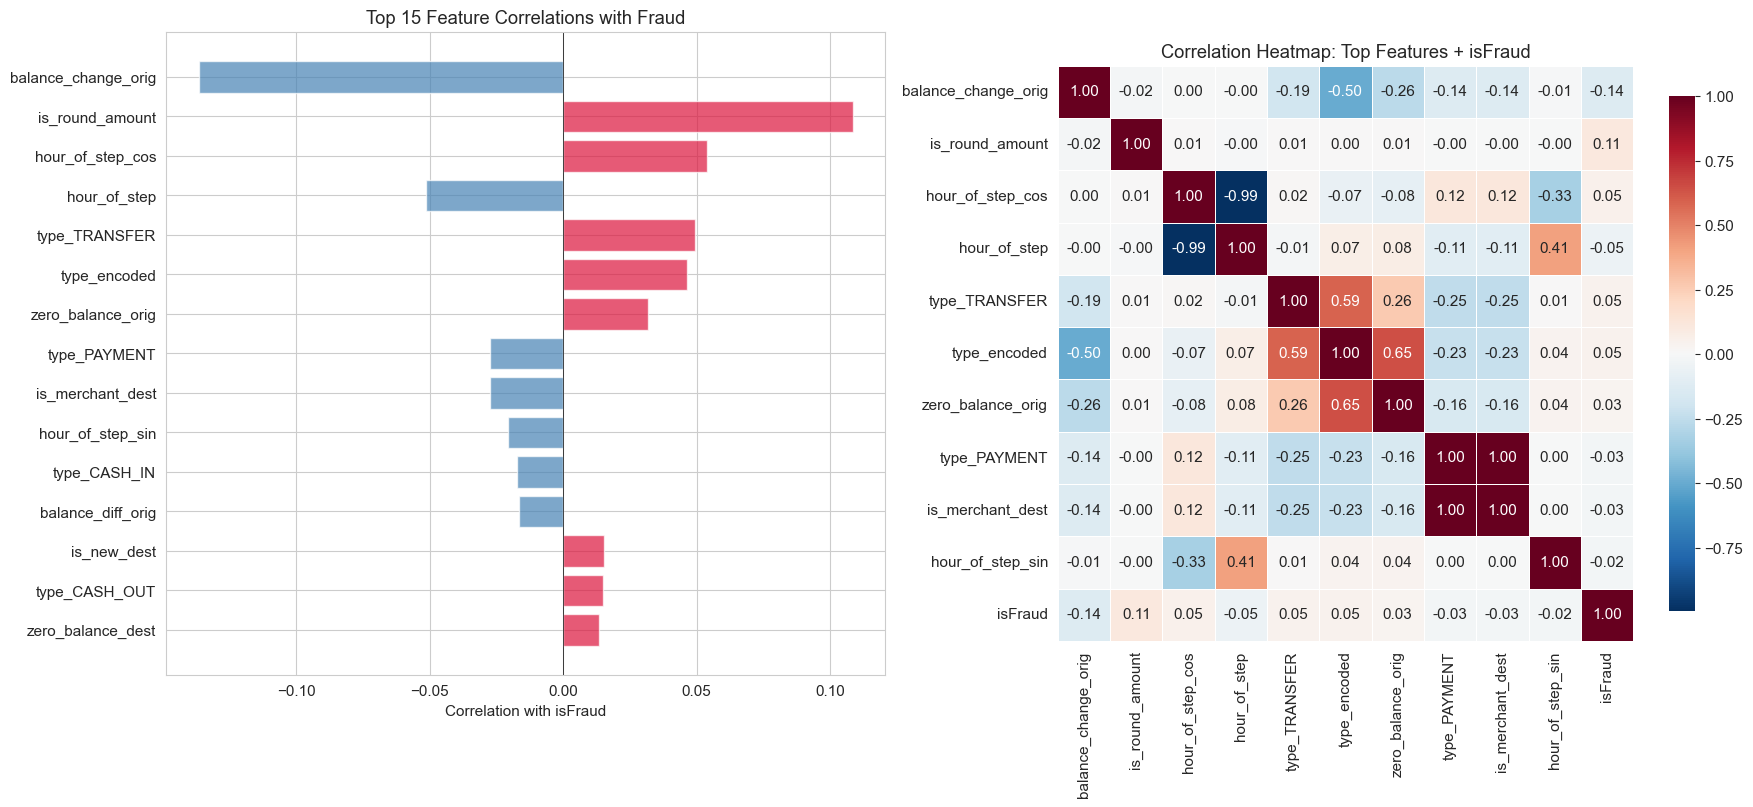

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: Correlation Analysis — Which Features Predict Fraud?
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("CORRELATION ANALYSIS: Features vs isFraud")
print("=" * 60)

# Compute correlation with isFraud
numeric_features = df[feature_cols].select_dtypes(include=[np.number])
corr_with_fraud = numeric_features.corrwith(df['isFraud']).sort_values(key=abs, ascending=False)

print(f"\nTop 10 features by absolute correlation with isFraud:")
print("-" * 50)
for i, (feat, corr) in enumerate(corr_with_fraud.head(10).items(), 1):
    direction = "↑" if corr > 0 else "↓"
    print(f"  {i:2d}. {feat:30s} | {corr:+.4f} {direction}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 15 correlations
top_n = 15
top_corr = corr_with_fraud.head(top_n)
colors = ['crimson' if v > 0 else 'steelblue' for v in top_corr.values]

axes[0].barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index)
axes[0].set_xlabel("Correlation with isFraud")
axes[0].set_title(f"Top {top_n} Feature Correlations with Fraud")
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].invert_yaxis()

# Correlation heatmap of top features
top_features = top_corr.head(10).index.tolist() + ['isFraud']
corr_matrix = df[top_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlation Heatmap: Top Features + isFraud")

plt.tight_layout()
plt.show()

FEATURE DISTRIBUTIONS BY FRAUD CLASS


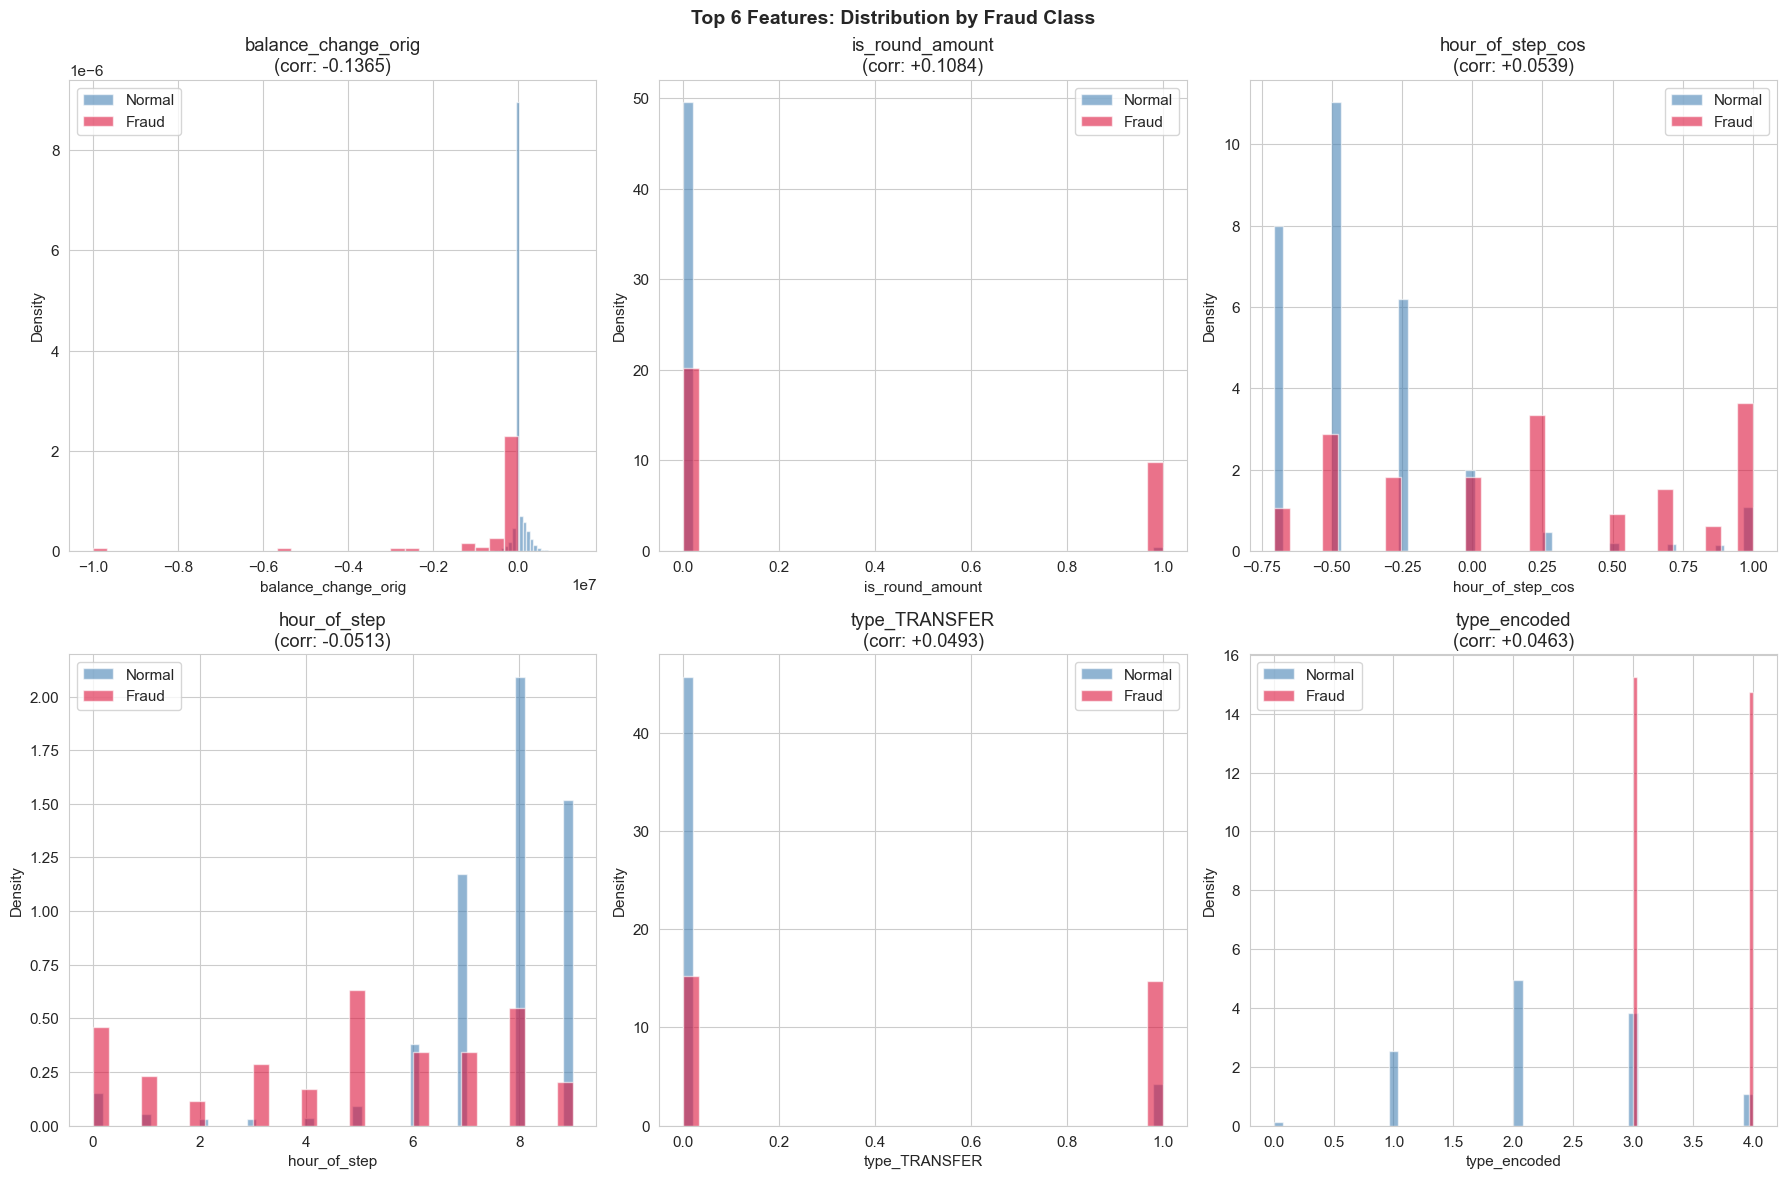

In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: Feature Distributions — Fraud vs Normal
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("FEATURE DISTRIBUTIONS BY FRAUD CLASS")
print("=" * 60)

# Select top 6 features by correlation for detailed comparison
top_6_features = corr_with_fraud.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

fraud_mask = df['isFraud'] == 1

for i, feat in enumerate(top_6_features):
    ax = axes[i]
    
    # Get data
    normal_data = df.loc[~fraud_mask, feat]
    fraud_data = df.loc[fraud_mask, feat]
    
    # Handle different scales
    if feat in ['balance_diff_orig', 'balance_diff_dest', 'amount_to_balance_ratio']:
        # Log scale for large-range features
        normal_plot = np.log1p(normal_data.clip(lower=0))
        fraud_plot = np.log1p(fraud_data.clip(lower=0))
        xlabel = f"log1p({feat})"
    else:
        normal_plot = normal_data
        fraud_plot = fraud_data
        xlabel = feat
    
    ax.hist(normal_plot, bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(fraud_plot, bins=30, alpha=0.6, label='Fraud', color='crimson', density=True)
    ax.set_title(f"{feat}\n(corr: {corr_with_fraud[feat]:+.4f})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Top 6 Features: Distribution by Fraud Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: Save Engineered Features
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("SAVING ENGINEERED FEATURES")
print("=" * 60)

# Ensure output directory exists
FEATURES_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save to CSV
df.to_csv(FEATURES_PATH, index=False)

file_size_mb = FEATURES_PATH.stat().st_size / (1024 * 1024)

print(f"Saved to: {FEATURES_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"File size: {file_size_mb:.1f} MB")
print(f"Features engineered: {len(feature_cols)}")

print(f"\n{'='*60}")
print("DAY 3 COMPLETE")
print(f"{'='*60}")
print(f"Output: {FEATURES_PATH}")
print(f"Ready for Day 4: Model Training (train.py)")

SAVING ENGINEERED FEATURES
Saved to: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features_sample.csv
Shape: 100,000 rows × 35 columns
File size: 21.7 MB
Features engineered: 24

DAY 3 COMPLETE
Output: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features_sample.csv
Ready for Day 4: Model Training (train.py)


In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15: Generate Production features.py Module (SELF-CONTAINED)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("GENERATING PRODUCTION MODULE: src/features.py")
print("=" * 60)

import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Resolve project root (notebook is in notebooks/, go up one level)
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

features_py_code = '''"""
src/features.py — Feature Engineering Pipeline for LedgerWatch AI

Day 3: Feature Engineering
==========================
Engineers 16 features from cleaned PaySim data based on EDA insights.
All features are computable on NEW transactions (no future leakage).
Labels (isFraud) are NEVER used during feature engineering.

Input:  data/processed/cleaned.csv  (6.3M rows, 11 cols)
Output: data/processed/features.csv (6.3M rows, 27 cols)

Features:
---------
1.  amount_log              — Log-transformed amount
2.  is_round_amount         — Round amount flag
3.  amount_to_balance_ratio — Sender liquidity stress
4.  balance_diff_orig       — Origin balance anomaly magnitude
5.  balance_diff_dest       — Destination balance anomaly magnitude
6.  balance_change_orig     — Signed origin balance change
7.  balance_change_dest     — Signed destination balance change
8.  zero_balance_orig       — Sender emptied account
9.  zero_balance_dest       — Recipient started at zero
10. hour_of_step            — Hour of day (0-23)
11. hour_of_step_sin        — Cyclical encoding (sin)
12. hour_of_step_cos        — Cyclical encoding (cos)
13. type_encoded            — Ordinal by fraud risk
14. type_CASH_IN            — One-hot dummy
15. type_CASH_OUT           — One-hot dummy
16. type_DEBIT              — One-hot dummy
17. type_PAYMENT            — One-hot dummy
18. type_TRANSFER           — One-hot dummy
19. freq_orig               — Expanding count per sender
20. freq_dest               — Expanding count per recipient
21. is_new_orig             — First transaction for sender
22. is_new_dest             — First transaction for recipient
23. is_merchant_orig        — Sender is merchant
24. is_merchant_dest        — Recipient is merchant

Author: Kalpit
Date: June 12, 2026
"""

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Optional
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path(__file__).resolve().parent.parent
CLEANED_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"


def engineer_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    """Amount-based features: log transform, round flag, liquidity ratio."""
    df["amount_log"] = np.log1p(df["amount"])
    df["is_round_amount"] = (df["amount"] % 1.0 == 0).astype(int)
    df["amount_to_balance_ratio"] = df.apply(
        lambda row: row["amount"] / row["oldbalanceOrg"]
        if row["oldbalanceOrg"] > 0 else row["amount"],
        axis=1
    )
    ratio_cap = df["amount_to_balance_ratio"].quantile(0.999)
    df["amount_to_balance_ratio"] = df["amount_to_balance_ratio"].clip(upper=ratio_cap)
    return df


def engineer_balance_features(df: pd.DataFrame) -> pd.DataFrame:
    """Balance-based features: diff magnitudes, changes, zero flags."""
    df["balance_diff_orig"] = (df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]).abs()
    df["balance_diff_dest"] = (df["oldbalanceDest"] - df["newbalanceDest"] + df["amount"]).abs()
    df["balance_change_orig"] = df["newbalanceOrig"] - df["oldbalanceOrg"]
    df["balance_change_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]
    df["zero_balance_orig"] = (df["newbalanceOrig"] == 0).astype(int)
    df["zero_balance_dest"] = (df["oldbalanceDest"] == 0).astype(int)
    return df


def engineer_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Temporal features: hour extraction + cyclical sin/cos encoding."""
    df["hour_of_step"] = (df["step"] - 1) % 24
    df["hour_of_step_sin"] = np.sin(2 * np.pi * df["hour_of_step"] / 24)
    df["hour_of_step_cos"] = np.cos(2 * np.pi * df["hour_of_step"] / 24)
    return df


def engineer_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """Categorical features: ordinal encoding + one-hot dummies."""
    type_risk_map = {"TRANSFER": 4, "CASH_OUT": 3, "PAYMENT": 2, "CASH_IN": 1, "DEBIT": 0}
    df["type_encoded"] = df["type"].map(type_risk_map)
    type_dummies = pd.get_dummies(df["type"], prefix="type", dtype=int)
    df = pd.concat([df, type_dummies], axis=1)
    return df


def engineer_frequency_features(df: pd.DataFrame) -> pd.DataFrame:
    """Frequency features: EXPANDING count (no data leakage)."""
    df = df.sort_values("step").reset_index(drop=True)
    df["freq_orig"] = df.groupby("nameOrig").cumcount()
    df["freq_dest"] = df.groupby("nameDest").cumcount()
    df["is_new_orig"] = (df["freq_orig"] == 0).astype(int)
    df["is_new_dest"] = (df["freq_dest"] == 0).astype(int)
    return df


def engineer_merchant_features(df: pd.DataFrame) -> pd.DataFrame:
    """Merchant features: C=customer, M=merchant prefix flags."""
    df["is_merchant_orig"] = df["nameOrig"].str.startswith("M").astype(int)
    df["is_merchant_dest"] = df["nameDest"].str.startswith("M").astype(int)
    return df


def engineer_all_features(
    input_path: Optional[Path] = None,
    output_path: Optional[Path] = None,
    save: bool = True
) -> pd.DataFrame:
    """Main pipeline: load -> engineer -> validate -> save."""
    input_path = input_path or CLEANED_PATH
    output_path = output_path or FEATURES_PATH

    logger.info("=" * 60)
    logger.info("LEDGERWATCH AI — Feature Engineering Pipeline")
    logger.info("=" * 60)

    logger.info(f"Loading: {input_path}")
    if not input_path.exists():
        raise FileNotFoundError(f"Cleaned data not found at {input_path}")

    df = pd.read_csv(input_path, low_memory=False)
    logger.info(f"Loaded {len(df):,} rows x {len(df.columns)} cols")

    df = engineer_amount_features(df)
    df = engineer_balance_features(df)
    df = engineer_temporal_features(df)
    df = engineer_categorical_features(df)
    df = engineer_frequency_features(df)
    df = engineer_merchant_features(df)

    # Validation
    original_cols = [
        "step", "type", "amount", "nameOrig", "oldbalanceOrg",
        "newbalanceOrig", "nameDest", "oldbalanceDest",
        "newbalanceDest", "isFraud", "isFlaggedFraud"
    ]
    feature_cols = [c for c in df.columns if c not in original_cols]

    assert df[feature_cols].isna().sum().sum() == 0, "NaNs found in features!"
    assert not np.isinf(df[feature_cols].select_dtypes(include=[np.number])).any().any(), "Infinities found!"
    assert "isFraud" not in feature_cols, "Label leakage detected!"

    if save:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(output_path, index=False)
        logger.info(f"Saved: {output_path} ({output_path.stat().st_size / (1024*1024):.1f} MB)")

    logger.info(f"Features: {len(feature_cols)} | Total cols: {len(df.columns)} | Rows: {len(df):,}")
    return df


if __name__ == "__main__":
    engineer_all_features()
'''

# Write to file
src_path = PROJECT_ROOT / "src" / "features.py"
src_path.parent.mkdir(parents=True, exist_ok=True)

with open(src_path, "w") as f:
    f.write(features_py_code)

print(f"✅ Written to: {src_path}")
print(f"   Size: {src_path.stat().st_size:,} bytes")

# Verify it can be imported
try:
    from src.features import engineer_all_features
    print(f"✅ Import test passed: from src.features import engineer_all_features")
except Exception as e:
    print(f"⚠️  Import test failed: {e}")

GENERATING PRODUCTION MODULE: src/features.py
✅ Written to: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\src\features.py
   Size: 7,028 bytes
✅ Import test passed: from src.features import engineer_all_features
